# Components & Factories

kfactory ships a library of **built-in photonic components** under `kf.cells` and the
**factories** that generate them under `kf.factories`.

| Component | Cell function | Factory |
|---|---|---|
| Straight waveguide | `kf.cells.straight.straight` | `kf.factories.straight.straight_dbu_factory` |
| Euler bend | `kf.cells.euler.bend_euler` | `kf.factories.euler.bend_euler_factory` |
| Euler S-bend | `kf.cells.euler.bend_s_euler` | `kf.factories.euler.bend_s_euler_factory` |
| Circular bend | `kf.cells.circular.bend_circular` | `kf.factories.circular.bend_circular_factory` |
| Taper | `kf.cells.taper.taper` | `kf.factories.taper.taper_factory` |
| Bezier S-bend | `kf.cells.bezier.bend_s` | `kf.factories.bezier.bend_s_bezier_factory` |

## Cells vs. Factories

Every **cell function** under `kf.cells.*` uses the built-in demo `KCLayout` instance
(`kf.cells.demo`). These are convenient for quick prototyping and learning.

A **factory** is a function that *creates* a cell function bound to a specific
`KCLayout`. When you build your own PDK you call the factory once, passing your
layout, and get back a cell function that creates geometry in that layout:

```python
my_straight = kf.factories.straight.straight_dbu_factory(kcl=my_kcl)
wg = my_straight(width=500, length=10_000, layer=LAYER.WG)
```

This page demonstrates both patterns side by side.

## Setup

In [1]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    SLAB: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)


L = LAYER()
kf.kcl.infos = L

## Straight waveguide

`kf.cells.straight.straight` creates a rectangle of material with optional
slab/exclude layers defined by a `LayerEnclosure`.

```
┌──────────────────────────────┐
│         Slab/Exclude         │
├──────────────────────────────┤
│                              │
│             Core             │
│                              │
├──────────────────────────────┤
│         Slab/Exclude         │
└──────────────────────────────┘
```

Arguments are in **µm** (the `um` variant). All coordinates are converted to DBU
internally. There is also a `straight_dbu` function for DBU-native code.

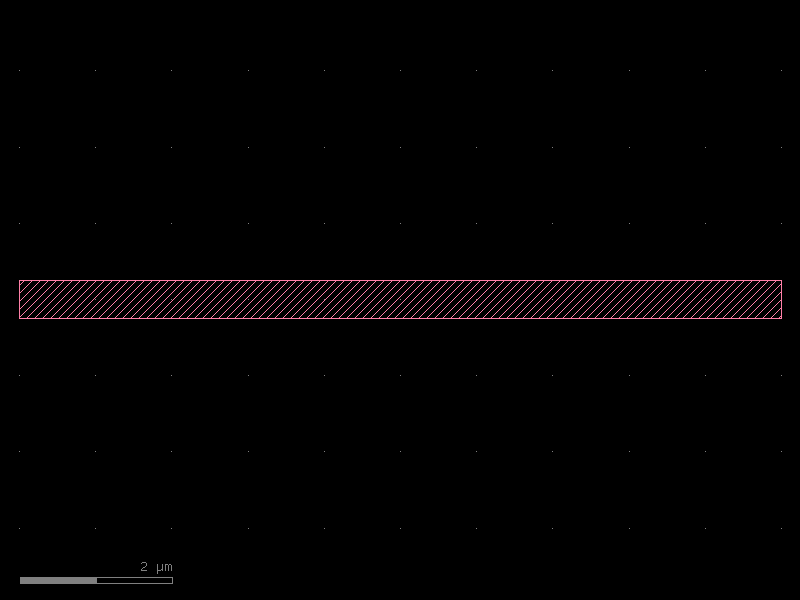

In [2]:
from kfactory.cells.straight import straight

# Simple straight — no cladding
wg = straight(width=0.5, length=10.0, layer=L.WG)
wg.plot()

### With cladding via LayerEnclosure

Wrap the core with an oxide/slab layer using `LayerEnclosure`:

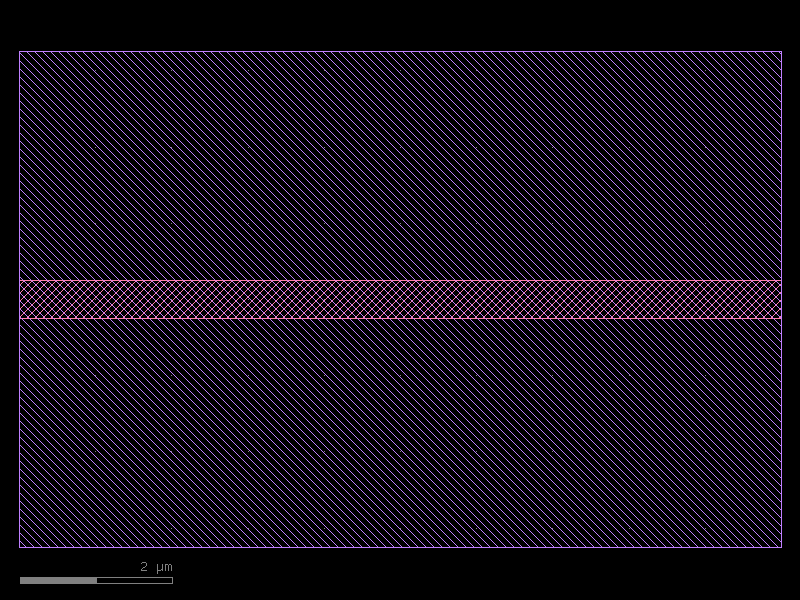

In [3]:
enc = kf.LayerEnclosure(
    dsections=[(L.WGCLAD, 3)],  # 3 µm cladding on all sides
    kcl=kf.kcl,
)

wg_clad = straight(width=0.5, length=10.0, layer=L.WG, enclosure=enc)
wg_clad.plot()

### Using the factory directly

For PDK work, bind a straight factory to your `KCLayout`:

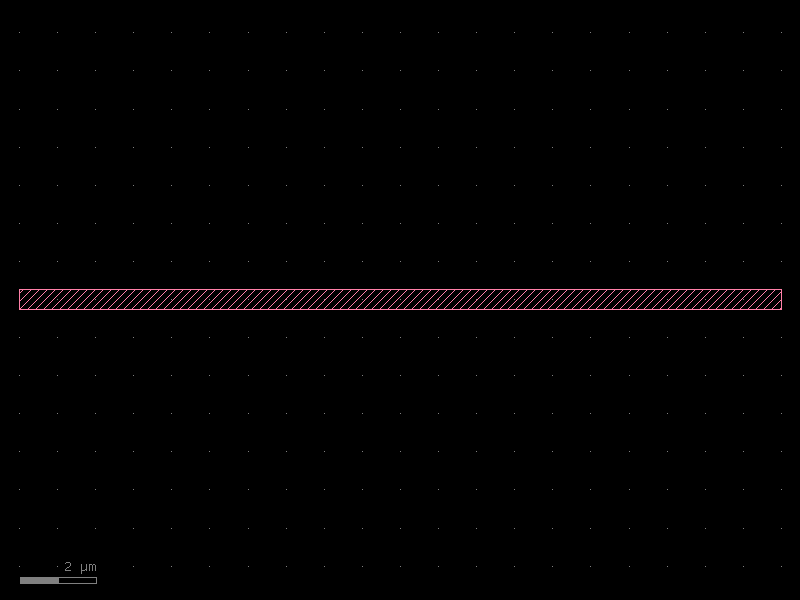

In [4]:
from kfactory.factories.straight import straight_dbu_factory

my_straight = straight_dbu_factory(kcl=kf.kcl)

# Dimensions in DBU (1 µm = 1000 dbu at default 1 nm/dbu)
wg_dbu = my_straight(
    width=kf.kcl.to_dbu(0.5),
    length=kf.kcl.to_dbu(20.0),
    layer=L.WG,
)
wg_dbu.plot()

## Euler bend

An **Euler bend** (clothoid bend) has a radius that varies continuously from 0 at the
input to a maximum value at the midpoint and back to 0 at the output. This minimises
mode mismatch and reflection compared to a circular bend of the same nominal radius.

Key parameters:
- `width` — waveguide core width \[µm\]
- `radius` — nominal radius of the backbone \[µm\]
- `angle` — total angle swept (default 90°)
- `resolution` — number of backbone segments per 360° (default 150)

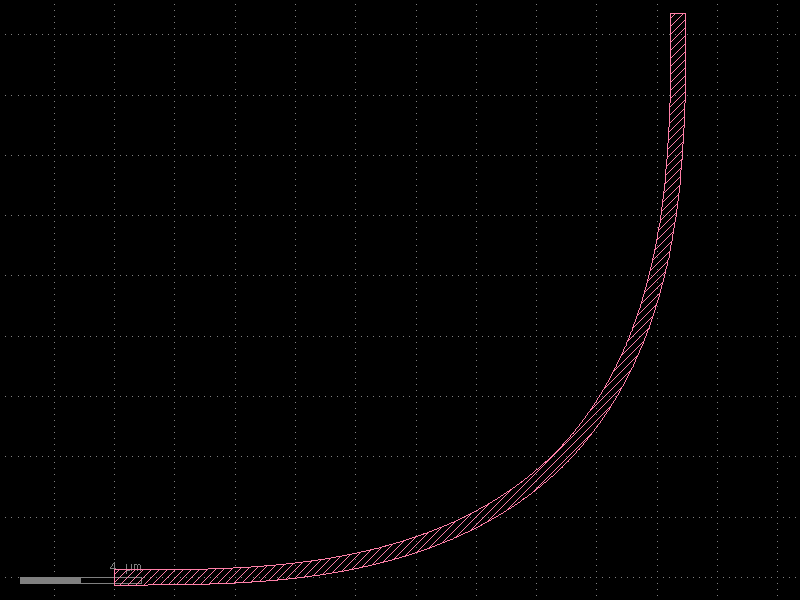

In [5]:
from kfactory.cells.euler import bend_euler

bend = bend_euler(width=0.5, radius=10.0, layer=L.WG)
bend.plot()

### Euler bend — custom angle

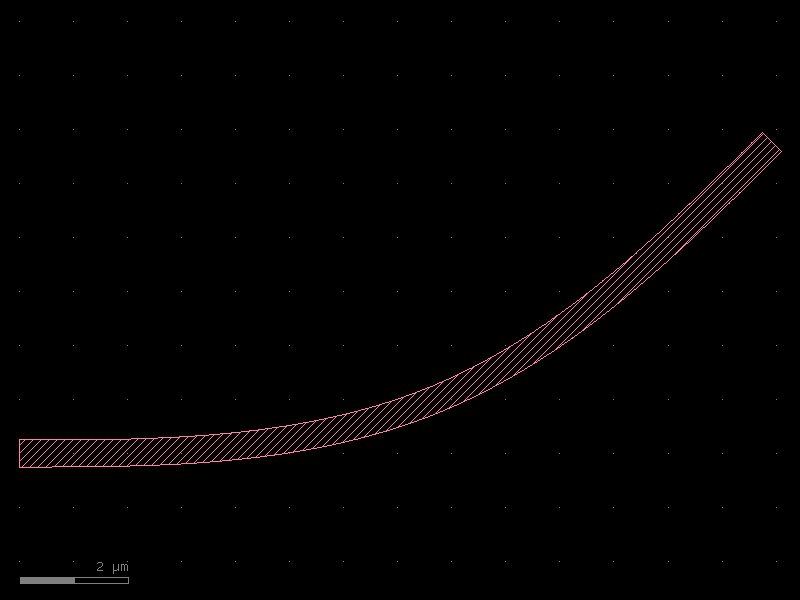

In [6]:
bend_45 = bend_euler(width=0.5, radius=10.0, layer=L.WG, angle=45)
bend_45.plot()

### Euler S-bend

An Euler S-bend offsets two ports laterally by `offset` µm. The backbone consists of
two Euler quarter-circles joined at their inflection point.

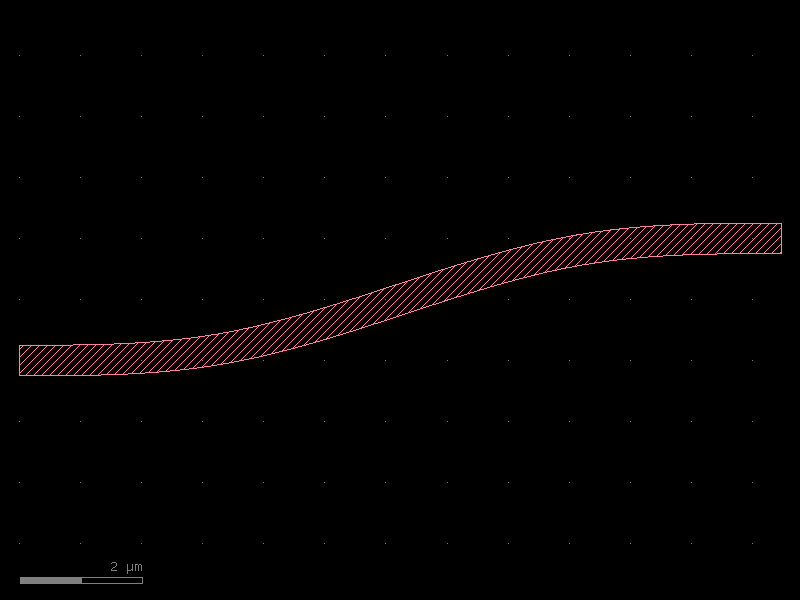

In [7]:
from kfactory.cells.euler import bend_s_euler

sbend = bend_s_euler(offset=2.0, width=0.5, radius=10.0, layer=L.WG)
sbend.plot()

### Euler factory — PDK usage

Bind an Euler factory to your layout to create bends that live in your PDK:

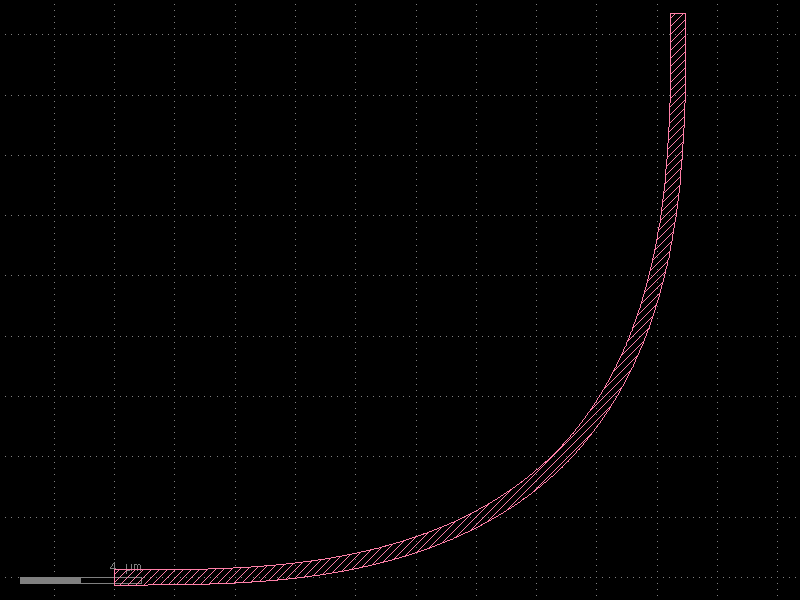

In [8]:
from kfactory.factories.euler import bend_euler_factory

my_bend_euler = bend_euler_factory(kcl=kf.kcl)
pdk_bend = my_bend_euler(width=0.5, radius=10.0, layer=L.WG)
pdk_bend.plot()

## Circular bend

A **circular bend** has a *constant* radius throughout. It is faster to compute than
an Euler bend but has higher mode mismatch at the junction with a straight waveguide.

Key parameters:
- `width` — waveguide core width \[µm\]
- `radius` — constant bend radius \[µm\]
- `angle` — angle swept (default 90°)
- `angle_step` — angular resolution (default 1° per point)

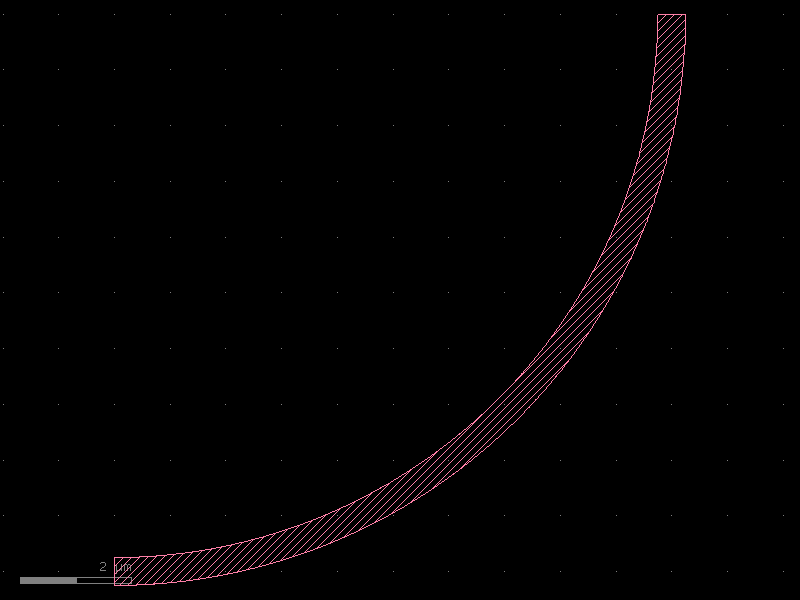

In [9]:
from kfactory.cells.circular import bend_circular

circ = bend_circular(width=0.5, radius=10.0, layer=L.WG)
circ.plot()

### Circular bend — 180°

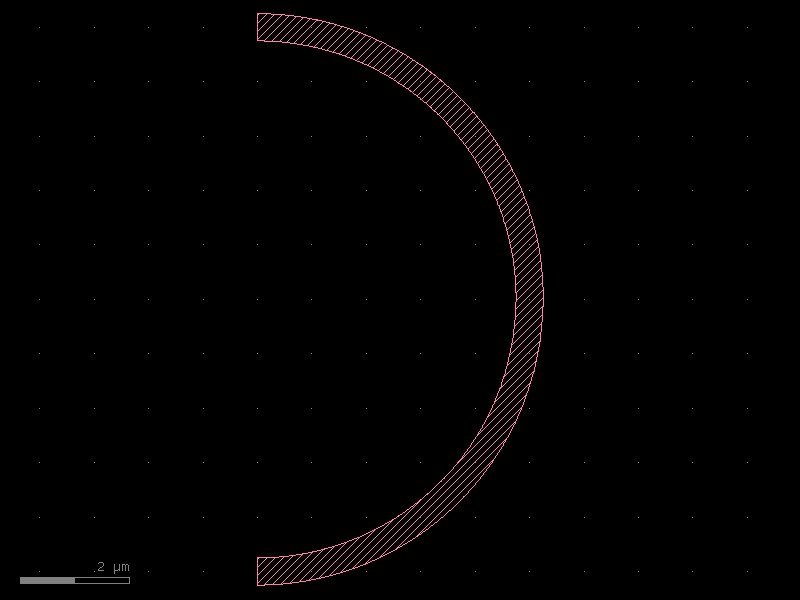

In [10]:
circ_180 = bend_circular(width=0.5, radius=5.0, layer=L.WG, angle=180)
circ_180.plot()

## Taper

A **linear taper** transitions between two different waveguide widths. Typical uses:
- Mode-field adapter between a narrow routing waveguide and a wide MMI port.
- Spot-size converter at a chip facet.

```
           __
         _/  │
       _/  __│
     _/  _/  │
    │  _/    │ Core
    │_/      │
    │_       │
    │ \_     │
    │_  \_   │
      \_  \__│
        \_   │
          \__│
```

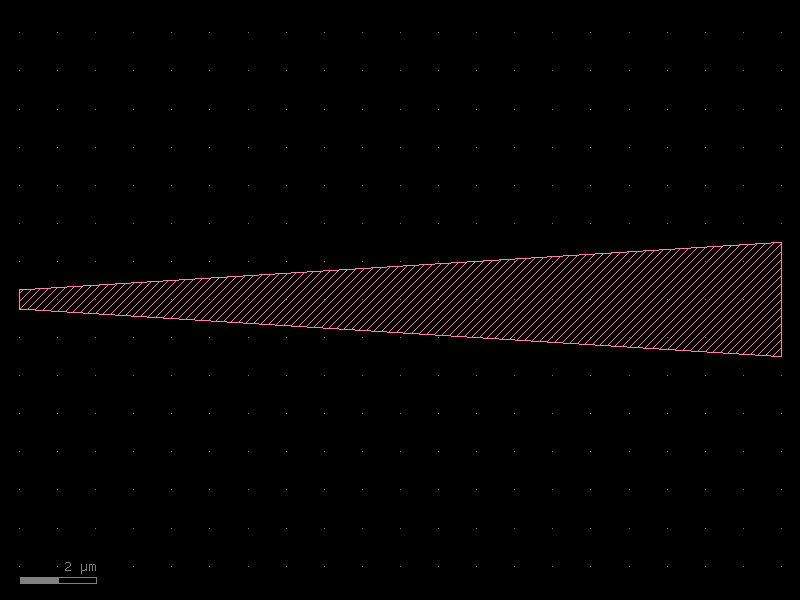

In [11]:
from kfactory.cells.taper import taper

t = taper(width1=0.5, width2=3.0, length=20.0, layer=L.WG)
t.plot()

### Taper with cladding

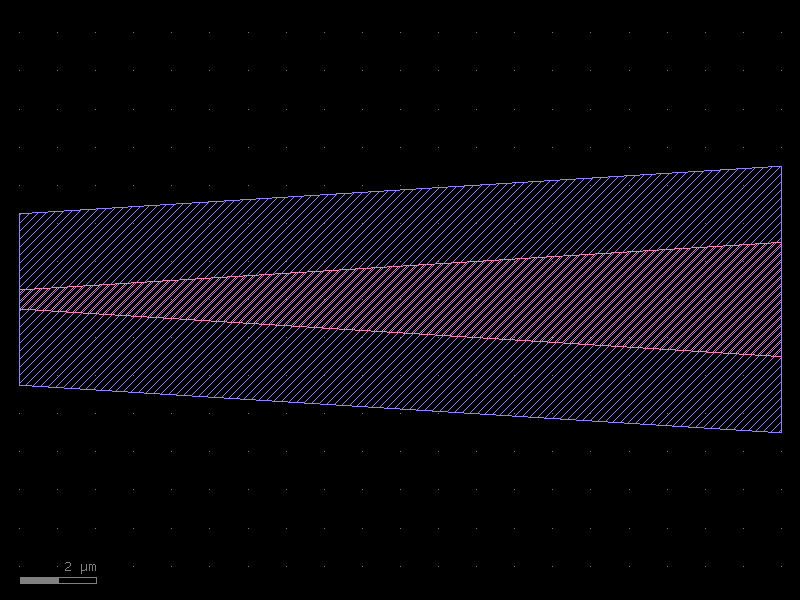

In [12]:
enc_slab = kf.LayerEnclosure(dsections=[(L.SLAB, 2)], kcl=kf.kcl)

t_clad = taper(width1=0.5, width2=3.0, length=20.0, layer=L.WG, enclosure=enc_slab)
t_clad.plot()

## Bezier S-bend

A **Bezier S-bend** uses a cubic Bezier curve to create a smooth lateral offset. It
offers more shape control than an Euler S-bend (via `t_start`/`t_stop`).

Key parameters:
- `width` — waveguide width \[µm\]
- `height` — lateral offset between the two ports \[µm\]
- `length` — horizontal span of the bend \[µm\]
- `nb_points` — backbone resolution (default 99)

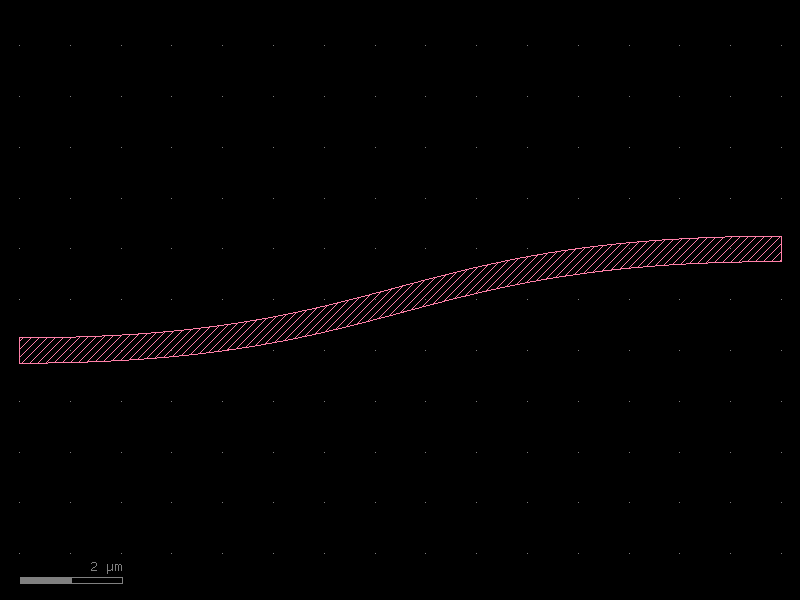

In [13]:
from kfactory.cells.bezier import bend_s

bez = bend_s(width=0.5, height=2.0, length=15.0, layer=L.WG)
bez.plot()

## Building your own PDK components

The factory pattern lets you create component functions that are:
1. **Bound to your layout** — geometry lands in the right `KCLayout`.
2. **Cached automatically** — calling with the same params returns the same cell.
3. **Named consistently** — cell names embed all parameters for traceability.

### Example: custom PDK with two components

Cell name: 'my_waveguide_W0p45_L5'
Ports: ['o1', 'o2']


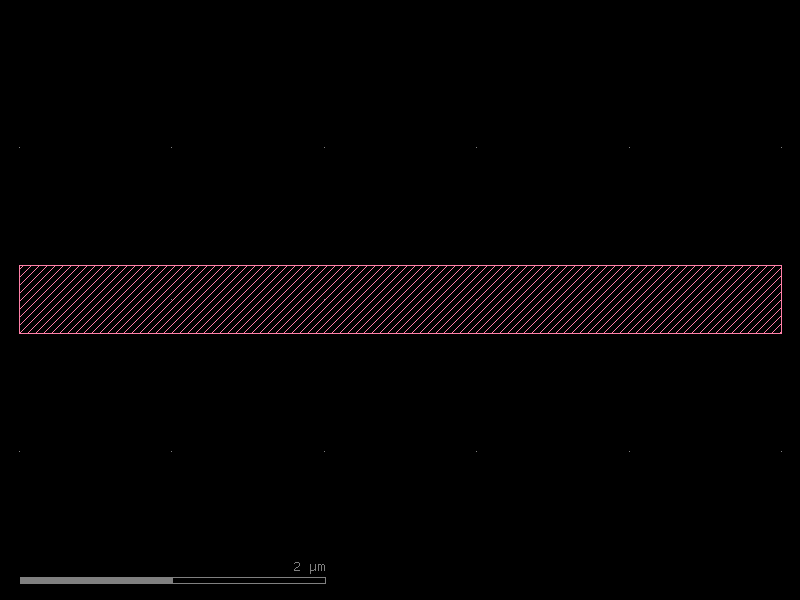

In [14]:
# Create a dedicated layout for "MyPDK"
my_pdk = kf.KCLayout("MyPDK")
my_pdk.infos = L  # reuse the same layer definitions


# Build factory-backed cell functions
@kf.cell
def my_waveguide(width: float, length: float) -> kf.KCell:
    """Straight waveguide using MyPDK's layout.

    Args:
        width: Core width [µm].
        length: Waveguide length [µm].
    """
    c = kf.KCell()
    c.shapes(c.kcl.find_layer(L.WG)).insert(
        kf.kdb.DBox(0, -width / 2, length, width / 2)
    )
    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, 0, 0),
            layer=c.kcl.find_layer(L.WG),
            width=kf.kcl.to_dbu(width),
            port_type="optical",
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            trans=kf.kdb.Trans(0, False, kf.kcl.to_dbu(length), 0),
            layer=c.kcl.find_layer(L.WG),
            width=kf.kcl.to_dbu(width),
            port_type="optical",
        )
    )
    return c


wg_custom = my_waveguide(width=0.45, length=5.0)
print(f"Cell name: {wg_custom.name!r}")
print(f"Ports: {[p.name for p in wg_custom.ports]}")
wg_custom.plot()

### Caching in action

The `@kf.cell` decorator caches cells by their parameter signature. Calling the same
function with the same arguments returns the *identical* cell object:

In [15]:
wg_a = my_waveguide(width=0.5, length=10.0)
wg_b = my_waveguide(width=0.5, length=10.0)
wg_c = my_waveguide(width=0.5, length=20.0)  # different params → new cell

print(f"wg_a is wg_b: {wg_a is wg_b}")  # True — same cached cell
print(f"wg_a is wg_c: {wg_a is wg_c}")  # False — different length

wg_a is wg_b: True
wg_a is wg_c: False


## Assembling components

Use the `<<` operator to place cell instances and `connect()` to snap ports:

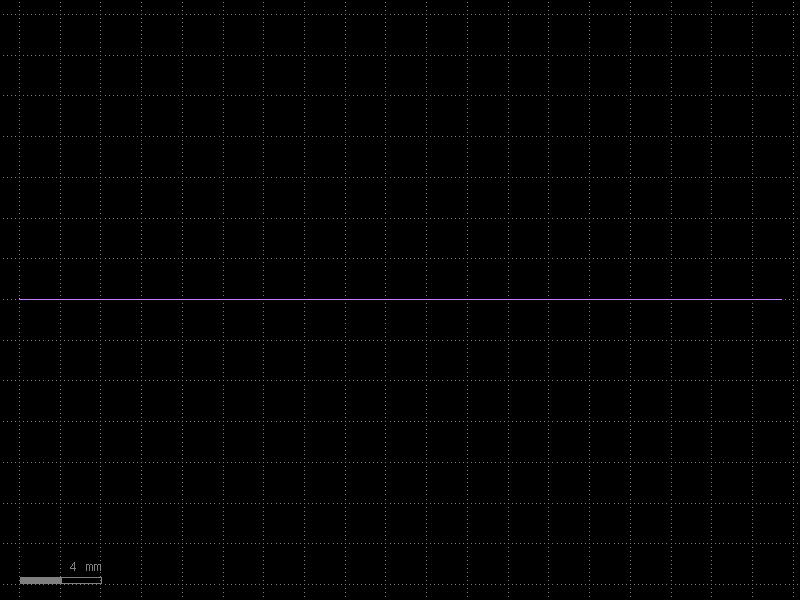

In [16]:
@kf.cell
def mzi_stub() -> kf.KCell:
    """A minimal MZI stub — two bends connected via straights."""
    c = kf.KCell()

    enc = kf.LayerEnclosure(dsections=[(L.WGCLAD, 2)], kcl=kf.kcl)

    # Bend instances (euler)
    b1 = c << bend_euler(width=0.5, radius=10.0, layer=L.WG)
    b2 = c << bend_euler(width=0.5, radius=10.0, layer=L.WG)
    b3 = c << bend_euler(width=0.5, radius=10.0, layer=L.WG)
    b4 = c << bend_euler(width=0.5, radius=10.0, layer=L.WG)

    # Connect bends into a U-shape
    b2.connect("o1", b1.ports["o2"])
    b3.connect("o1", b2.ports["o2"])
    b4.connect("o1", b3.ports["o2"])

    # Straight arm between b1 and b4
    arm_length = kf.routing.optical.get_radius(
        bend_euler(width=0.5, radius=10.0, layer=L.WG)
    )
    s1 = c << straight(width=0.5, length=arm_length * 2, layer=L.WG, enclosure=enc)
    s1.connect("o1", b4.ports["o2"])

    c.add_ports(b1.ports.filter(port_type="optical", regex="o1"))
    c.add_ports(s1.ports.filter(port_type="optical", regex="o2"))
    c.auto_rename_ports()
    return c


mzi = mzi_stub()
mzi.plot()

## See Also

| Topic | Where |
|-------|-------|
| Straight waveguide deep-dive | [Components: Straight](factories/straight.py) |
| Euler (clothoid) bends | [Components: Euler Bends](factories/euler.py) |
| Circular (constant-radius) bends | [Components: Circular Bends](factories/circular.py) |
| Width tapers | [Components: Tapers](factories/taper.py) |
| Bezier S-bends | [Components: Bezier](factories/bezier.py) |
| Virtual (non-physical) cells | [Components: Virtual Cells](virtual.py) |
| PCells & caching | [Components: PCells](pcells.py) |
| Factory functions reference | [Components: Factories](factories/overview.py) |
| KCell / DKCell / VKCell | [Core Concepts: KCell](../../concepts/kcell.py) |